#Chat Metrics

##Data Collection

In [1]:
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
import graphviz

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  roc_auc_score,
  classification_report
)
from sklearn import tree

df = pd.read_parquet('https://huggingface.co/datasets/ddds-Capstone/Datasets/resolve/main/chat_metrics.parquet')

##Processing

In [2]:
features = [
  'month_sin',
  'primary_category_navigation',
  'output_tokens',
  'answer_sentiment',
  'hour_sin',
  'model_calls',
  'primary_category_sunport_amenities',
  'day_sin',
  'question_length',
  'total_tokens'
]

X = df[features]
y = df['satisfaction']

###Train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42,
  stratify=y #Maintains roughly same proportion
)

###Scale

In [4]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42
)

#Initialize scaler
scaler = StandardScaler()

#Fit and transform training data
X_train = scaler.fit_transform(X_train)

#Transform (DO NOT fit again)
X_test = scaler.transform(X_test)

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#Split scaled data
X_train, X_test, y_train, y_test = train_test_split(
  X_scaled,
  y,
  test_size=0.20,
  random_state=42
)

###Logistic Regression

In [5]:
#Create model
lr = LogisticRegression()

#Fit
lr.fit(X_train, y_train)

#Make predictions
y_pred_lr = lr.predict(X_test)

#Probability
y_prob_lr = lr.predict_proba(X_test)[:,1]

#Evaluate
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Precision:', precision_score(y_test, y_pred_lr))
print('Recall:', recall_score(y_test, y_pred_lr))
print('F1:', f1_score(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_lr))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7126436781609196
Precision: 0.7317073170731707
Recall: 0.6818181818181818
F1: 0.7058823529411765
ROC-AUC: 0.7357293868921776

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72        43
           1       0.73      0.68      0.71        44

    accuracy                           0.71        87
   macro avg       0.71      0.71      0.71        87
weighted avg       0.71      0.71      0.71        87



In [6]:
#Cross Validation
#Use X_scaled to fix convergence issues and 'accuracy' for classification
results = cross_val_score(
  lr,
  X_scaled,
  y,
  scoring='accuracy',
  cv=10
)

#Accuracy across  10 folds
cv_accuracy = results.mean()
print('CV Accuracy:', cv_accuracy)

CV Accuracy: 0.7087209302325581


###Decision Tree

In [7]:
#Model
dt = DecisionTreeClassifier(
  max_depth=3,
  random_state=42
)

#Fit
dt.fit(X_train, y_train)

#Predict
y_pred_dt = dt.predict(X_test)

#Probability
y_prob_dt = dt.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1:', f1_score(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6551724137931034
Precision: 0.6346153846153846
Recall: 0.75
F1: 0.6875
ROC-AUC: 0.7404862579281184

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.56      0.62        43
           1       0.63      0.75      0.69        44

    accuracy                           0.66        87
   macro avg       0.66      0.65      0.65        87
weighted avg       0.66      0.66      0.65        87



In [8]:
#Cross Validation
scores = cross_val_score(
  dt,
  X_train,
  y_train,
  cv=5,
  scoring='accuracy'
)

print('CV Accuracy Scores for each fold:', scores)
print('Mean CV Accuracy:', scores.mean())

CV Accuracy Scores for each fold: [0.60869565 0.60869565 0.71014493 0.69565217 0.71014493]
Mean CV Accuracy: 0.6666666666666667


In [9]:
#Find depth
depths = range(1,11)

results = []

for depth in depths:

  tree_model = DecisionTreeClassifier(
    max_depth=depth,
    random_state=42
  )

  scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
9,10,0.692754
7,8,0.689855
3,4,0.689855
8,9,0.689855
4,5,0.686957
1,2,0.681159
5,6,0.675362
6,7,0.672464
2,3,0.666667
0,1,0.663768


In [20]:
#Final
dt = DecisionTreeClassifier(
  max_depth=10,
  random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1:', f1_score(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.735632183908046
Precision: 0.7142857142857143
Recall: 0.7954545454545454
F1: 0.7526881720430108
ROC-AUC: 0.734936575052854

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.67      0.72        43
           1       0.71      0.80      0.75        44

    accuracy                           0.74        87
   macro avg       0.74      0.73      0.73        87
weighted avg       0.74      0.74      0.73        87



In [21]:
#Feature importance
dt_importances = pd.Series(
  dt.feature_importances_,
  index=features
).sort_values(ascending=False)

dt_importances.head(10)

,0
output_tokens,0.258927
answer_sentiment,0.148891
month_sin,0.148599
total_tokens,0.143146
model_calls,0.110088
question_length,0.074134
hour_sin,0.073037
day_sin,0.019681
primary_category_navigation,0.016532
primary_category_sunport_amenities,0.006963


###Random Forest

In [22]:
rf = RandomForestClassifier(
  n_estimators=100, #Build 100 individual trees
  max_depth=3,      #Each tree grows max of 3 depths
  random_state=42,  #Makes results reproducable
  n_jobs=-1         #Uses all available CPU cores
)

#Fit
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Probability
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1:', f1_score(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6781609195402298
Precision: 0.6818181818181818
Recall: 0.6818181818181818
F1: 0.6818181818181818
ROC-AUC: 0.7885835095137421

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        43
           1       0.68      0.68      0.68        44

    accuracy                           0.68        87
   macro avg       0.68      0.68      0.68        87
weighted avg       0.68      0.68      0.68        87



In [23]:
#Tune max_depth
results = []

for depth in depths:

  rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=depth,
    random_state=42,
    n_jobs=-1
  )

  scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
3,4,0.744928
5,6,0.739130
6,7,0.739130
7,8,0.733333
4,5,0.733333
8,9,0.730435
9,10,0.727536
2,3,0.710145
1,2,0.701449
0,1,0.675362


In [24]:
#Tune n_estimators
n_estimators_values = [50, 100, 200, 300, 500]

results = []

for n in n_estimators_values:

  forest = RandomForestClassifier(
    n_estimators=n,
    max_depth=4,
    random_state=42,
    n_jobs=-1
  )

  scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  rmse_scores = -scores

  results.append({
    'n_estimators': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,n_estimators,accuracy
4,500,0.747826
1,100,0.744928
2,200,0.742029
0,50,0.727536
3,300,0.727536


In [25]:
#Final
rf = RandomForestClassifier(
  n_estimators=500,
  max_depth=4,
  random_state=42,
  n_jobs=-1
)

#Fit
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Probability
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1:', f1_score(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7126436781609196
Precision: 0.7021276595744681
Recall: 0.75
F1: 0.7252747252747253
ROC-AUC: 0.7996828752642706

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70        43
           1       0.70      0.75      0.73        44

    accuracy                           0.71        87
   macro avg       0.71      0.71      0.71        87
weighted avg       0.71      0.71      0.71        87



###XGBoost

In [26]:
#Create baseline model
xgb = XGBClassifier(
  n_estimators=100,   #Boosting rounds/trees
  learning_rate=0.05, #Controls how much each new tree contributest to model
  max_depth=3,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7241379310344828
Precision: 0.7272727272727273
Recall: 0.7272727272727273
F1: 0.7272727272727273
ROC-AUC: 0.8049682875264271

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        43
           1       0.73      0.73      0.73        44

    accuracy                           0.72        87
   macro avg       0.72      0.72      0.72        87
weighted avg       0.72      0.72      0.72        87



In [27]:
#Tune max_depth
results = []

for depth in depths:

  xgb = XGBClassifier(
    n_estimators=100,
    max_depth=depth,
    random_state=42,
    objective = 'binary:logistic', # Tells XGBoost to do binary classification
    eval_metric='logloss'
  )

  scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
7,8,0.742029
1,2,0.736232
2,3,0.736232
5,6,0.733333
0,1,0.730435
8,9,0.724638
9,10,0.721739
3,4,0.718841
4,5,0.718841
6,7,0.718841


In [28]:
#Tune n_estimators
n_estimators_values = [50, 100, 200, 300, 500]

results = []

for n in n_estimators_values:

  forest = XGBClassifier(
    n_estimators=n,
    max_depth=8,
    random_state=42,
    objective = 'binary:logistic', # Tells XGBoost to do binary classification
    eval_metric='logloss'
  )

  scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'n_estimators': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,n_estimators,accuracy
3,300,0.750725
2,200,0.747826
4,500,0.744928
1,100,0.742029
0,50,0.736232


In [29]:
#Tune learning_rate
learning_rates = [0.01, 0.05, 0.1, 0.2]

results = []

for n in learning_rates:

  xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=n,
    max_depth=8,
    random_state=42,
    objective = 'reg:squarederror'
  )

  scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  rmse_scores = -scores

  results.append({
    'learning_rate': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,learning_rate,accuracy
0,0.01,0.701449
1,0.05,0.698551
2,0.10,0.695652
3,0.20,0.681159


In [30]:
#Final XGBoost model
xgb = XGBClassifier(
  n_estimators=300,   #Boosting rounds/trees
  learning_rate=0.01, #Controls how much each new tree contributest to model
  max_depth=8,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7471264367816092
Precision: 0.7291666666666666
Recall: 0.7954545454545454
F1: 0.7608695652173914
ROC-AUC: 0.8202959830866807

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73        43
           1       0.73      0.80      0.76        44

    accuracy                           0.75        87
   macro avg       0.75      0.75      0.75        87
weighted avg       0.75      0.75      0.75        87



In [31]:
#Feature importance
xgb_importances = pd.Series(
  xgb.feature_importances_,
  index=features
).sort_values(ascending=False)

xgb_importances.head(10)

,0
output_tokens,0.202720
month_sin,0.175503
model_calls,0.114689
primary_category_navigation,0.107302
answer_sentiment,0.093258
question_length,0.075142
hour_sin,0.068447
total_tokens,0.062895
primary_category_sunport_amenities,0.062485
day_sin,0.037559


##Data Visualization

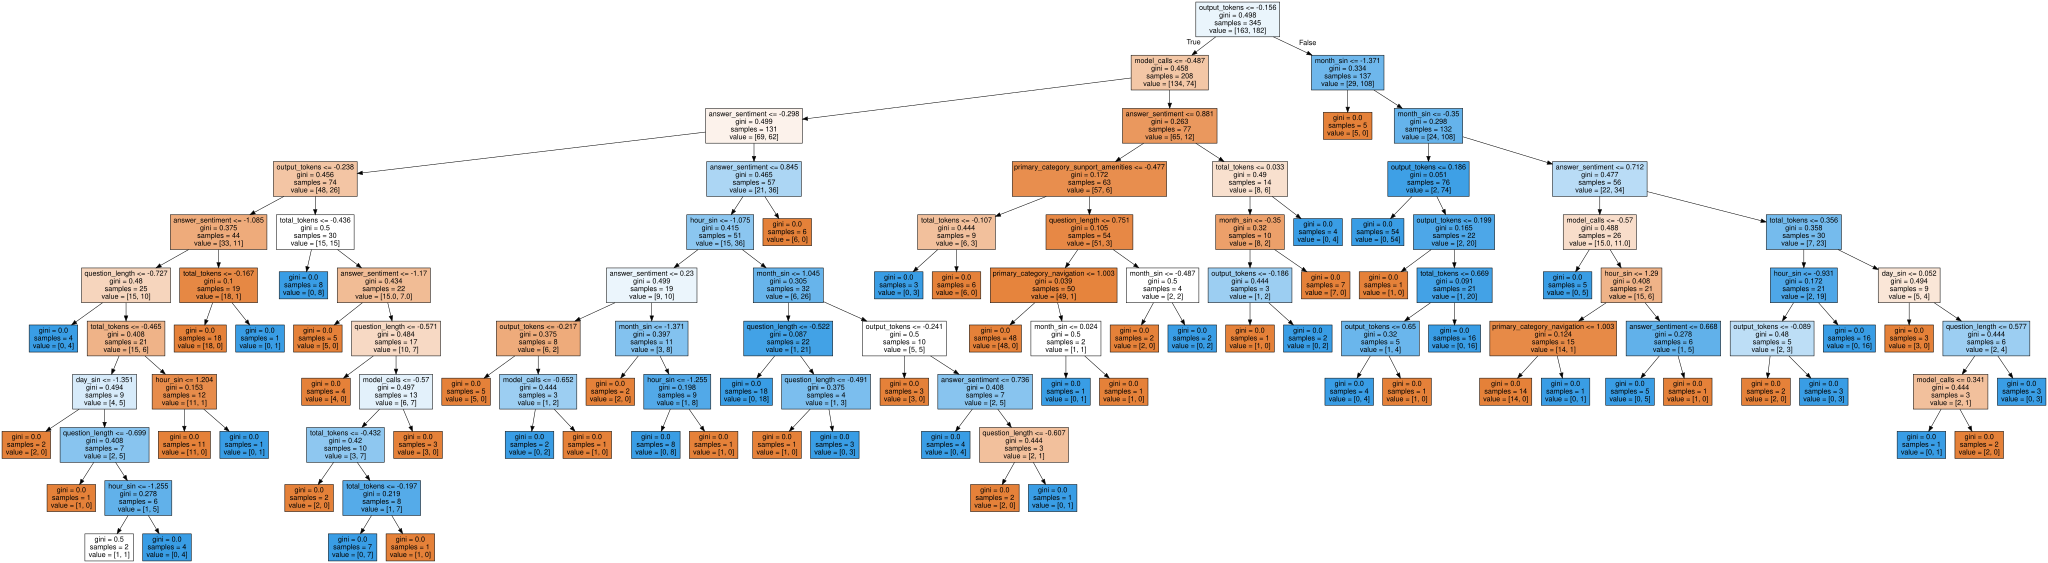

In [32]:
display(
  graphviz.Source(
    tree.export_graphviz(
      dt,
      feature_names = X.columns,
      filled = True,
    )))

<Axes: title={'center': 'Decision Tree Feature Importance'}>

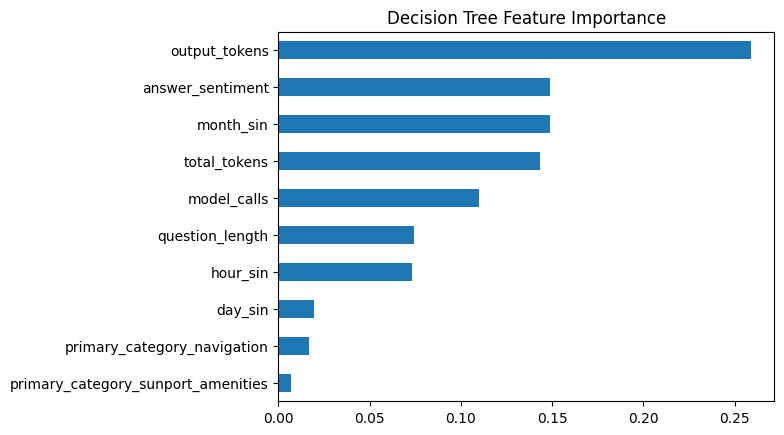

In [33]:
dt_importances.head(10).sort_values().plot(
  kind='barh',
  title='Decision Tree Feature Importance'
)

<Axes: title={'center': 'Random Forest Feature Importance'}>

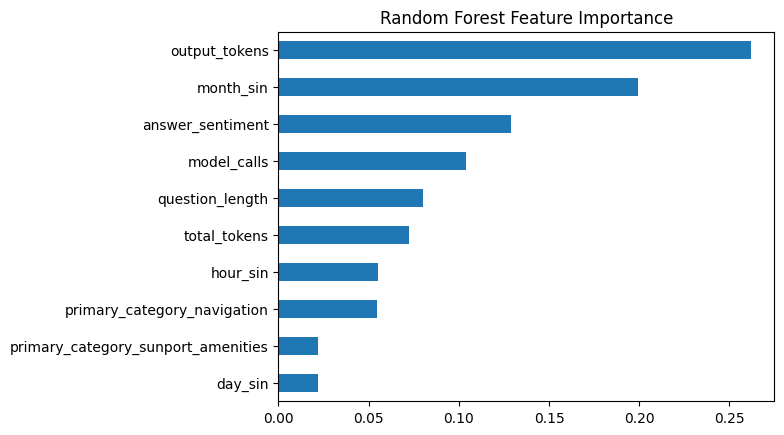

In [34]:
#Feature importance
forest_importances = pd.Series(
  rf.feature_importances_,
  index=features
).sort_values(ascending=False)

#Plot
forest_importances.head(10).sort_values().plot(
  kind='barh',
  title='Random Forest Feature Importance'
)

<Axes: title={'center': 'XGBoost Feature Importance'}>

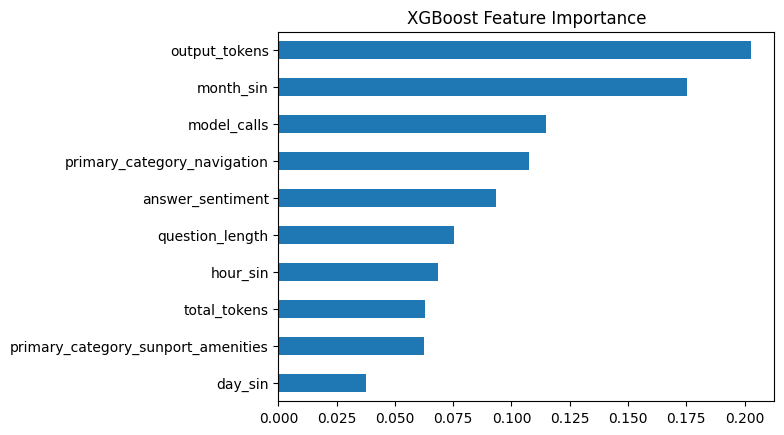

In [35]:
xgb_importances.head(10).sort_values().plot(
  kind='barh',
  title='XGBoost Feature Importance'
)

In [36]:
results = pd.DataFrame({
  'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],

  'Accuracy': [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
  ],

  'F1': [
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
  ],

  'ROC-AUC': [
    roc_auc_score(y_test, y_prob_dt),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
  ]
})

results

,Model,Accuracy,F1,ROC-AUC
0,Decision Tree,0.735632,0.752688,0.734937
1,Random Forest,0.712644,0.725275,0.799683
2,XGBoost,0.747126,0.760870,0.820296


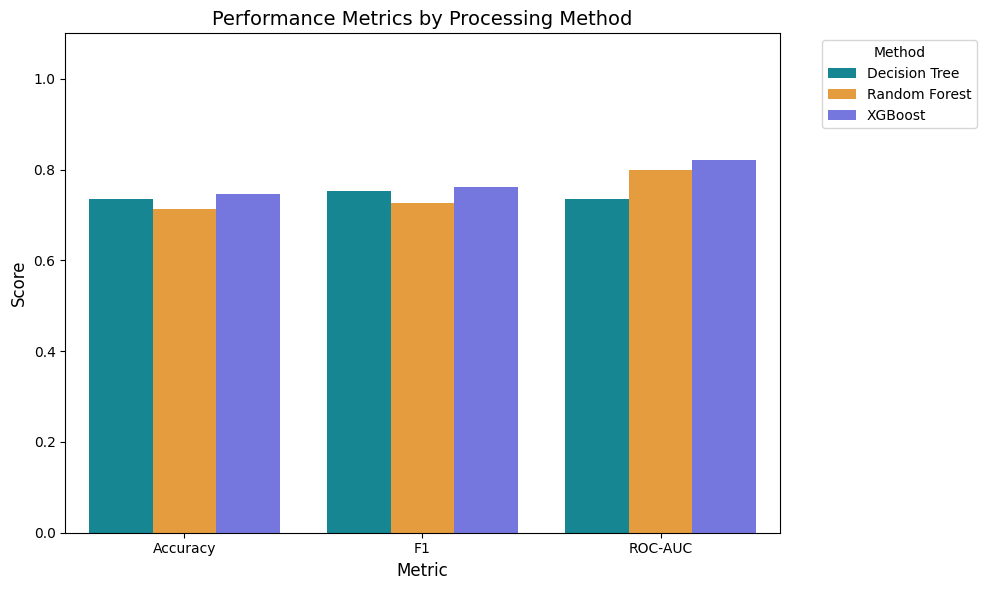

In [37]:
#Melt df to restructure for Seaborn
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette=['#0097A7', '#FF9F24',  '#6366F1']
)

plt.title('Performance Metrics by Processing Method', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.ylim(0, 1.1) #Headroom

#Move legend
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('evaluation.png', dpi=300, bbox_inches='tight')

plt.show()

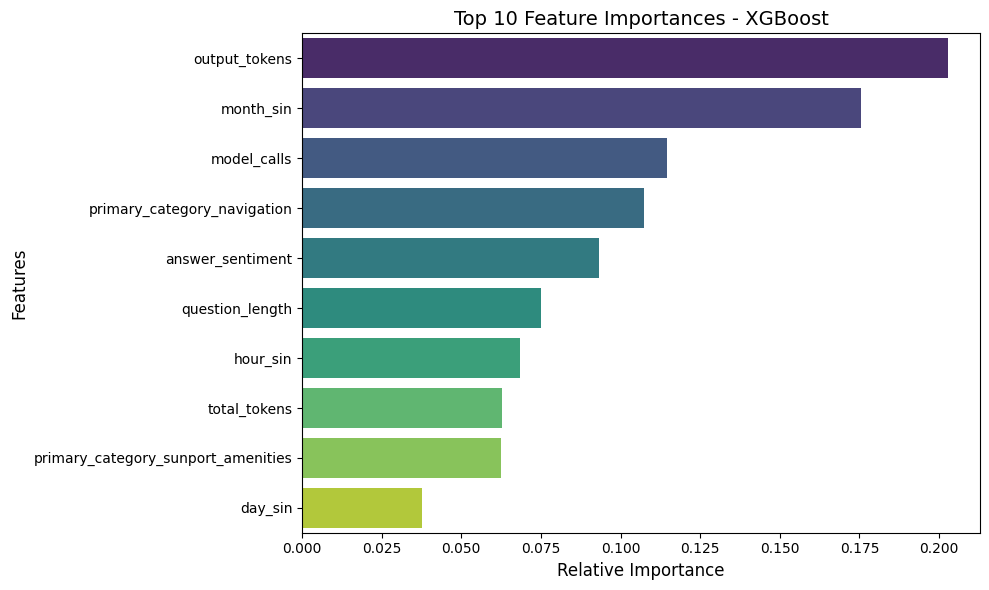

In [38]:
#Create df for XGBoost importance features
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))

#Create horizontal barplot
sns.barplot(
    data=feature_importance.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Feature Importances - XGBoost', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()

plt.savefig('important_features.png', dpi=300, bbox_inches='tight')

plt.show()

##Communication of Results

In [39]:
importance_comparison = pd.DataFrame({
  'Decision Tree': dt_importances,
  'Random Forest': forest_importances,
  'XGBoost': xgb_importances
})

importance_comparison

,Decision Tree,Random Forest,XGBoost
answer_sentiment,0.148891,0.129184,0.093258
day_sin,0.019681,0.021761,0.037559
hour_sin,0.073037,0.055043,0.068447
model_calls,0.110088,0.103936,0.114689
month_sin,0.148599,0.199247,0.175503
output_tokens,0.258927,0.261907,0.202720
primary_category_navigation,0.016532,0.054605,0.107302
primary_category_sunport_amenities,0.006963,0.022059,0.062485
question_length,0.074134,0.080117,0.075142
total_tokens,0.143146,0.072141,0.062895
